In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# Set seed for reproducibility
np.random.seed(42)

In [6]:
# Load the iris dataset
iris_data = load_iris()
X = iris_data.data
y = iris_data.target # We will hide this and only use it for the final plot!

print(f"Dataset shape: {X.shape}")
print(f"Number of features: {X.shape[1]}")

Dataset shape: (150, 4)
Number of features: 4


In [7]:
# TODO: Calculate the mean and standard deviation of each feature (column)
mean_vector = X.mean(axis=0)
std_vector = X.std(axis=0)
# TODO: Standardize the data
X_scaled = (X-mean_vector)/std_vector

print("Mean of scaled data (should be close to 0):", np.mean(X_scaled, axis=0))
print("Std of scaled data (should be close to 1):", np.std(X_scaled, axis=0))


Mean of scaled data (should be close to 0): [-1.69031455e-15 -1.84297022e-15 -1.69864123e-15 -1.40924309e-15]
Std of scaled data (should be close to 1): [1. 1. 1. 1.]


In [8]:
# TODO: Compute the covariance matrix
cov_matrix = np.cov(X_scaled.T)

print("Covariance Matrix shape:", cov_matrix.shape)

Covariance Matrix shape: (4, 4)


In [9]:
# TODO: Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

print("Number of eigenvalues:", len(eigenvalues))

Number of eigenvalues: 4


In [10]:
# TODO: Get the indices that would sort the eigenvalues in descending order
sorted_indices = np.flip(np.argsort(eigenvalues))

# Sort eigenvalues and eigenvectors using the indices
sorted_eigenvalues = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[sorted_indices]

# Each PC's contribution and running (cumulative) contribution
explained_variance_ratio = sorted_eigenvalues / np.sum(sorted_eigenvalues)
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

print("Top 3 Eigenvalues:", sorted_eigenvalues[:3])
print("Top 3 explained variance ratios:", explained_variance_ratio[:3])
print("Cumulative explained variance (first 5 PCs):", cumulative_explained_variance[:5])

Top 3 Eigenvalues: [2.93808505 0.9201649  0.14774182]
Top 3 explained variance ratios: [0.72962445 0.22850762 0.03668922]
Cumulative explained variance (first 5 PCs): [0.72962445 0.95813207 0.99482129 1.        ]


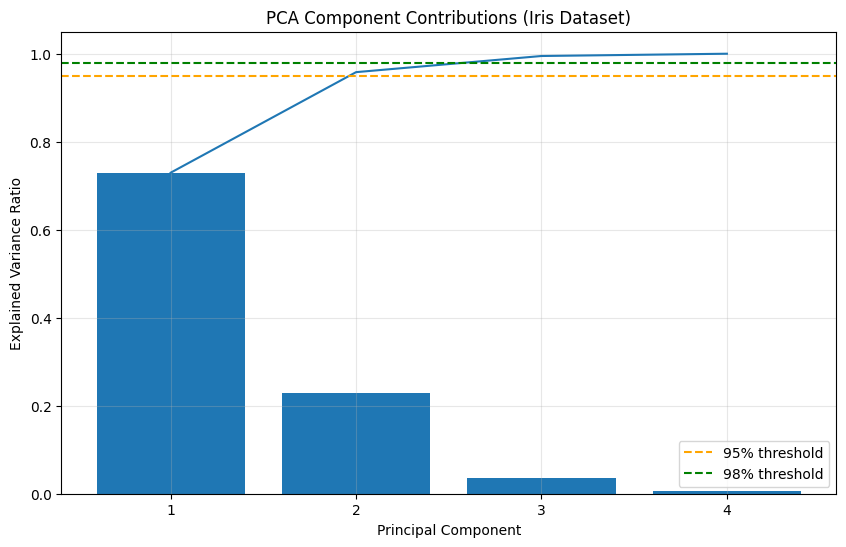

In [11]:
# TODO: Build x-axis values for principal components (1, 2, ..., n_components)
pc_indices = np.array([1,2,3,4])

plt.figure(figsize=(10, 6))

# TODO: Plot individual contribution as bars
plt.bar(pc_indices, explained_variance_ratio)

# TODO: Plot cumulative contribution as a line
plt.plot(pc_indices, cumulative_explained_variance)

# Optional guide lines to help choose k
plt.axhline(0.95, color='orange', linestyle='--', linewidth=1.5, label='95% threshold')
plt.axhline(0.98, color='green', linestyle='--', linewidth=1.5, label='98% threshold')

plt.xticks(pc_indices)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA Component Contributions (Iris Dataset)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [12]:
# TODO: Pick a target variance (try 0.95 or 0.98)
target_variance = 0.95

# TODO: Find the minimum number of PCs needed to reach target_variance
k = np.where(cumulative_explained_variance >= target_variance)[0][0] + 1

# TODO: Select top-k eigenvectors
eigenvector_subset = sorted_eigenvectors[:,:k]

# TODO: Project standardized data onto selected eigenvectors
X_reduced = X_scaled @ eigenvector_subset

print(f"Chosen target variance: {target_variance * 100:.0f}%")
print(f"Selected k: {k}")
print(f"Retained variance: {cumulative_explained_variance[k-1]:.4f}")
print("Original shape:", X.shape)
print("Reduced shape:", X_reduced.shape)

Chosen target variance: 95%
Selected k: 2
Retained variance: 0.9581
Original shape: (150, 4)
Reduced shape: (150, 2)


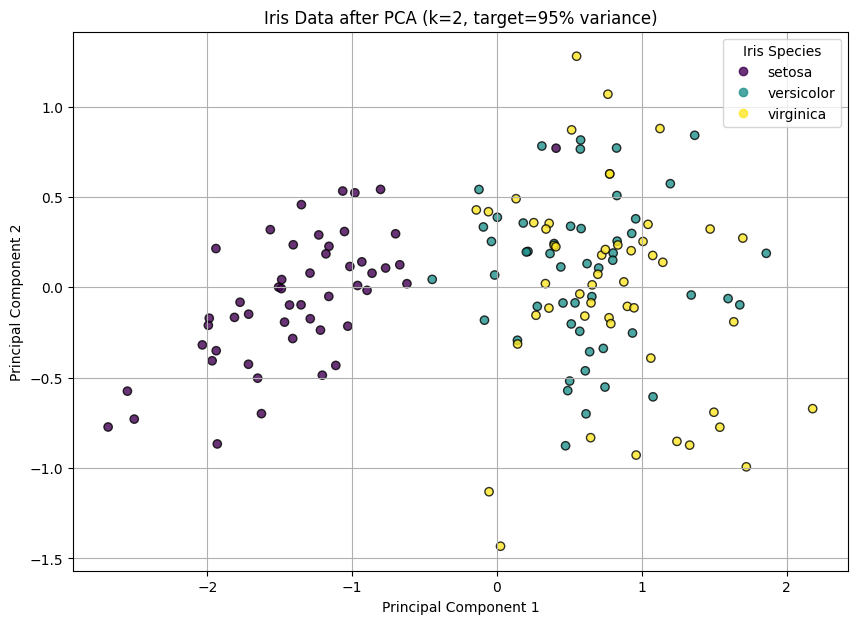

In [13]:
plt.figure(figsize=(10, 7))

if X_reduced.shape[1] >= 2:
    x_axis = X_reduced[:, 0]
    y_axis = X_reduced[:, 1]
    x_label = "Principal Component 1"
    y_label = "Principal Component 2"
else:
    # Fallback for rare case when only 1 PC is retained
    x_axis = X_reduced[:, 0]
    y_axis = np.zeros_like(X_reduced[:, 0])
    x_label = "Principal Component 1"
    y_label = "Zero axis (only 1 PC retained)"

# Scatter plot colored by the actual iris classes
scatter = plt.scatter(x_axis, y_axis, c=y, cmap='viridis', alpha=0.8, edgecolor='k')

# Adding a legend
plt.legend(handles=scatter.legend_elements()[0], labels=iris_data.target_names.tolist(), title="Iris Species")

plt.title(f"Iris Data after PCA (k={X_reduced.shape[1]}, target={target_variance*100:.0f}% variance)")
plt.xlabel(x_label)
plt.ylabel(y_label)
plt.grid(True)
plt.show()